<a href="https://colab.research.google.com/github/guthasushmasree/ML-LabPrograms/blob/main/ml7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload your placement prediction CSV file


Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv

File uploaded: placement_predict_50k Dataset.csv

Dataset loaded successfully!
Dataset shape: (50000, 32)

First 5 rows:


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99



Training samples: 37500
Testing samples : 12500


/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


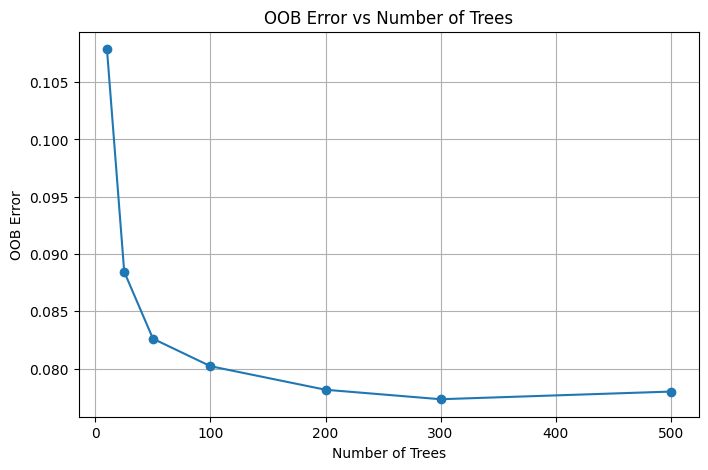


OOB Error Results:
n_estimators=10  OOB_error=0.1079
n_estimators=25  OOB_error=0.0885
n_estimators=50  OOB_error=0.0826
n_estimators=100 OOB_error=0.0802
n_estimators=200 OOB_error=0.0782
n_estimators=300 OOB_error=0.0773
n_estimators=500 OOB_error=0.0780

Feature Subsampling Results:
max_features=sqrt  OOB=0.9227 Test=0.9175
max_features=log2  OOB=0.9227 Test=0.9175
max_features=None  OOB=0.9189 Test=0.9144

What each source of randomness contributes:
    Single tree    test=0.8830
    Bagging only   test=0.9147
    Full forest    test=0.9175

Final Random Forest Results:
OOB Score  = 0.9227
OOB Error  = 0.0773
Test Score = 0.9175

Importance (Impurity vs Permutation):
                    impurity  permutation
CGPA                  0.2754       0.0995
HistoryOfBacklogs     0.0262       0.0171
Internships           0.0363       0.0136
SoftSkillsRating      0.0814       0.0136
Projects              0.0896       0.0092
CodingTestScore       0.1228       0.0052
MockInterviewScore    0.1

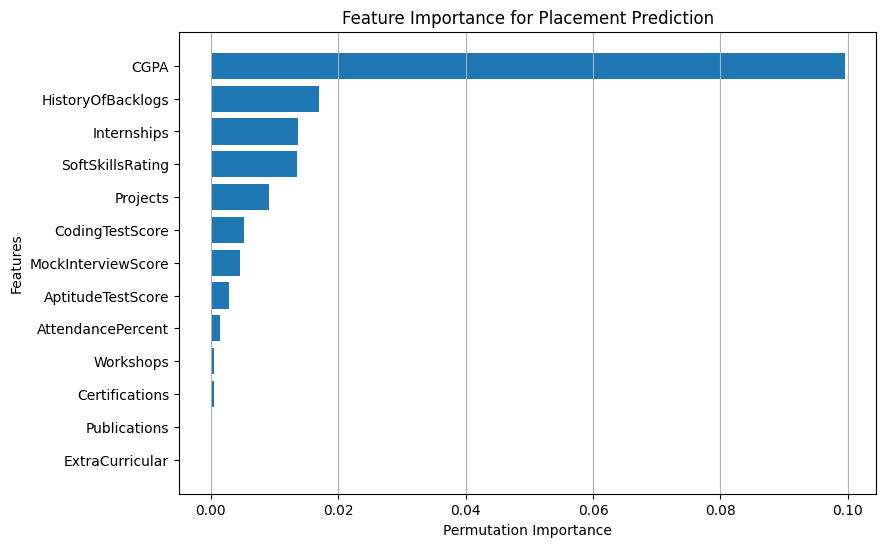


Experiment 7 completed successfully!
Random Forest - OOB, Bagging, Feature Subsampling


In [ ]:


import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance


print("Upload your placement prediction CSV file")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("\nFile uploaded:", filename)



df = pd.read_csv(filename)

print("\nDataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())



F = [
    "CGPA",
    "AttendancePercent",
    "HistoryOfBacklogs",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular"
]

X = df[F].copy()
y = df["PlacementStatus"].copy()


if X["HistoryOfBacklogs"].dtype == "object":

    X["HistoryOfBacklogs"] = X["HistoryOfBacklogs"].map({
        "Yes": 1,
        "No": 0
    })


if X["ExtraCurricular"].dtype == "object":

    X["ExtraCurricular"] = X["ExtraCurricular"].map({
        "Yes": 1,
        "No": 0
    })


for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")


X = X.fillna(X.median())


Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(Xtr))
print("Testing samples :", len(Xte))



n_range = [10, 25, 50, 100, 200, 300, 500]

oob = []

for n in n_range:

    model = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        random_state=0,
        n_jobs=-1
    )

    model.fit(Xtr, ytr)

    oob_error = 1 - model.oob_score_

    oob.append(oob_error)


# Plot OOB error

plt.figure(figsize=(8, 5))

plt.plot(
    n_range,
    oob,
    "o-"
)

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("OOB Error vs Number of Trees")

plt.grid(True)

plt.show()


print("\nOOB Error Results:")

for n, error in zip(n_range, oob):

    print(
        f"n_estimators={n:<3} "
        f"OOB_error={error:.4f}"
    )



print("\nFeature Subsampling Results:")

for mf in ["sqrt", "log2", None]:

    rf = RandomForestClassifier(
        n_estimators=300,
        max_features=mf,
        oob_score=True,
        random_state=0,
        n_jobs=-1
    )

    rf.fit(Xtr, ytr)

    print(
        f"max_features={str(mf):<5} "
        f"OOB={rf.oob_score_:.4f} "
        f"Test={rf.score(Xte, yte):.4f}"
    )



print("\nWhat each source of randomness contributes:")



single_tree = DecisionTreeClassifier(
    random_state=0
)

single_tree.fit(Xtr, ytr)

single_tree_score = single_tree.score(Xte, yte)


bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=300,
    random_state=0,
    n_jobs=-1
)

bagging.fit(Xtr, ytr)

bagging_score = bagging.score(Xte, yte)



forest = RandomForestClassifier(
    n_estimators=300,
    random_state=0,
    n_jobs=-1
)

forest.fit(Xtr, ytr)

forest_score = forest.score(Xte, yte)


print(
    f"    {'Single tree':<14} "
    f"test={single_tree_score:.4f}"
)

print(
    f"    {'Bagging only':<14} "
    f"test={bagging_score:.4f}"
)

print(
    f"    {'Full forest':<14} "
    f"test={forest_score:.4f}"
)



rf = RandomForestClassifier(
    n_estimators=300,
    oob_score=True,
    random_state=0,
    n_jobs=-1
)

rf.fit(Xtr, ytr)


print("\nFinal Random Forest Results:")

print(
    f"OOB Score  = {rf.oob_score_:.4f}"
)

print(
    f"OOB Error  = {1 - rf.oob_score_:.4f}"
)

print(
    f"Test Score = {rf.score(Xte, yte):.4f}"
)



perm = permutation_importance(
    rf,
    Xte,
    yte,
    n_repeats=20,
    random_state=0,
    n_jobs=-1
)


importance_df = pd.DataFrame(
    {
        "impurity": rf.feature_importances_,
        "permutation": perm.importances_mean
    },
    index=F
)


print("\nImportance (Impurity vs Permutation):")

print(
    importance_df
    .sort_values(
        "permutation",
        ascending=False
    )
    .round(4)
)



sorted_importance = (
    importance_df["permutation"]
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 6))

plt.barh(
    sorted_importance.index,
    sorted_importance.values
)

plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Feature Importance for Placement Prediction")

plt.grid(axis="x")

plt.show()


print("\n================================================")
print("Experiment 7 completed successfully!")
print("Random Forest - OOB, Bagging, Feature Subsampling")
print("================================================")